# Cross Validation

## Overview

This notebook demonstrates the public functions in `cross_validation` using a synthetic time-indexed classification dataset.
- The notebook creates feature, label, sample-weight, and label-horizon objects with aligned business-day indexes.
- It removes overlapping training labels, applies an embargo schedule, and inspects purged folds.
- It scores a classifier with purged cross-validation and visualizes the fold structure and scores.

In [1]:
from pathlib import Path
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
sys.path.insert(0, str(root))

np.random.seed(11)

In [2]:
from src.strategy_modeling.cross_validation import (
    PurgedKFold,
    get_embargo_times,
    get_train_times,
    score_cross_validation,
)

## Load And Prepare Synthetic Event Data

This section builds a compact event-labeled dataset for cross-validation.
- `make_classification` supplies the feature matrix and binary labels.
- A business-day index makes the sample behave like an ordered financial event table.
- `t1` assigns each event a five-business-day label horizon, which creates overlap that purging can remove.

In [3]:
X_np, y_np = make_classification(
    n_samples=180,
    n_features=6,
    n_informative=3,
    n_redundant=1,
    class_sep=0.9,
    shuffle=False,
    random_state=11,
)

dates = pd.date_range("2024-01-02", periods=180, freq="B")
X = pd.DataFrame(X_np, index=dates, columns=[f"feature_{i}" for i in range(6)])
y = pd.Series(y_np, index=dates, name="bin")
sample_weight = pd.Series(1.0, index=dates, name="w")
t1 = pd.Series(
    dates[np.minimum(np.arange(len(dates)) + 5, len(dates) - 1)],
    index=dates,
    name="t1",
)

data_summary = pd.Series(
    {
        "num_samples": len(X),
        "num_features": X.shape[1],
        "positive_label_rate": y.mean(),
        "first_event": X.index.min(),
        "last_event": X.index.max(),
        "median_horizon_days": (t1 - t1.index).dt.days.median(),
    }
)
data_summary

num_samples                            180
num_features                             6
positive_label_rate                    0.5
first_event            2024-01-02 00:00:00
last_event             2024-09-09 00:00:00
median_horizon_days                    7.0
dtype: object

### Interpretation

The synthetic event table has the same aligned objects expected by `PurgedKFold`: features, labels, weights, and label end times all share one business-day index.
- The current run contains `180` samples and `6` features, with labels close to balanced at about `0.49` positives.
- The median label horizon is `7` calendar days, so adjacent business-day observations overlap by design rather than being independent rows.
- That overlap is the reason ordinary K-fold validation would leak information from training labels into nearby test labels.

## Purge And Embargo Training Times

This section calls the helper functions directly before using the cross-validator.
- `get_train_times` removes labels whose start or end intervals overlap a selected test window.
- `get_embargo_times` maps each event timestamp to the timestamp after a fixed embargo fraction.
- Inspecting both helpers makes the fold-level behavior easier to validate.

In [4]:
test_times = pd.Series(
    t1.iloc[60:90].iloc[[0, -1]].values,
    index=t1.iloc[60:90].index[[0, -1]],
)
train_times = get_train_times(t1, test_times)
embargo_times = get_embargo_times(t1.index, pctEmbargo=0.05)

print(f"candidate labels: {len(t1)}")
print(f"labels kept after purge: {len(train_times)}")
print(f"labels removed by purge: {len(t1) - len(train_times)}")
print(f"first embargo end: {embargo_times.iloc[0]}")
print(f"last embargo end: {embargo_times.iloc[-1]}")
train_times.head()

candidate labels: 180
labels kept after purge: 158
labels removed by purge: 22
first embargo end: 2024-01-15 00:00:00
last embargo end: 2024-09-09 00:00:00


2024-01-02   2024-01-09
2024-01-03   2024-01-10
2024-01-04   2024-01-11
2024-01-05   2024-01-12
2024-01-08   2024-01-15
Name: t1, dtype: datetime64[us]

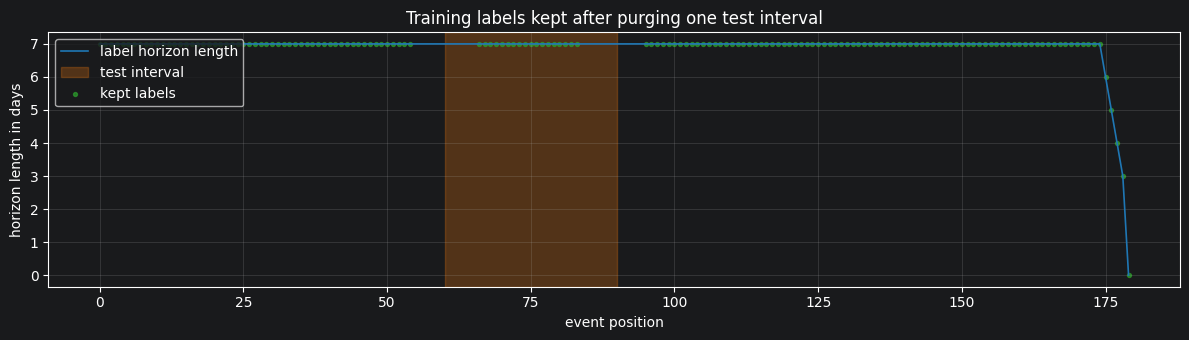

In [5]:
horizon_days = pd.Series((t1 - t1.index).dt.days, index=t1.index)
kept_positions = X.index.get_indexer(train_times.index)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(np.arange(len(horizon_days)), horizon_days.values, color="tab:blue", lw=1.2, label="label horizon length")
ax.axvspan(60, 90, color="tab:orange", alpha=0.25, label="test interval")
ax.scatter(kept_positions, horizon_days.loc[train_times.index].values, s=8, color="tab:green", alpha=0.7, label="kept labels")
ax.set_title("Training labels kept after purging one test interval")
ax.set_xlabel("event position")
ax.set_ylabel("horizon length in days")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()

### Interpretation

The purge helper removes only the labels that could overlap the selected test interval.
- From `180` candidate labels, the current test window leaves `158` labels and removes `22` labels.
- The embargo helper shifts the first event from `2024-01-02` to `2024-01-15`, matching a 5% embargo step of nine business observations.
- The last event maps to itself because there are no later observations available for an embargo extension.

## Run Purged Cross-Validation

This section uses `PurgedKFold` and `score_cross_validation` together.
- Each fold has a contiguous test block because the splitter preserves time order.
- Training sets are smaller near the middle folds because purging removes both preceding and following overlapping labels.
- The final score array is computed by fitting the classifier inside each purged fold.

In [6]:
cv_gen = PurgedKFold(n_splits=4, t1=t1, pctEmbargo=0.03)
fold_rows = []
fold_assignments = pd.Series("train", index=X.index, dtype="object")

for fold, (train_idx, test_idx) in enumerate(cv_gen.split(X), start=1):
    fold_rows.append(
        {
            "fold": fold,
            "train_size": len(train_idx),
            "test_size": len(test_idx),
            "test_start": X.index[test_idx[0]],
            "test_end": X.index[test_idx[-1]],
        }
    )
    fold_assignments.iloc[test_idx] = f"test_{fold}"

fold_summary = pd.DataFrame(fold_rows).set_index("fold")
fold_summary

,train_size,test_size,test_start,test_end
fold,,,,
1,126,45,2024-01-02,2024-03-04
2,122,45,2024-03-05,2024-05-06
3,122,45,2024-05-07,2024-07-08
4,131,45,2024-07-09,2024-09-09


In [7]:
clf = DecisionTreeClassifier(max_depth=3, random_state=11)
cv_scores = score_cross_validation(
    clf=clf,
    X=X,
    y=y,
    sample_weight=sample_weight,
    scoring="accuracy",
    t1=t1,
    cv=4,
    pctEmbargo=0.03,
)

score_summary = pd.Series(
    {
        "mean_accuracy": cv_scores.mean(),
        "std_accuracy": cv_scores.std(),
        "min_accuracy": cv_scores.min(),
        "max_accuracy": cv_scores.max(),
    }
)
score_summary

mean_accuracy    0.205556
std_accuracy     0.132753
min_accuracy     0.044444
max_accuracy     0.400000
dtype: float64

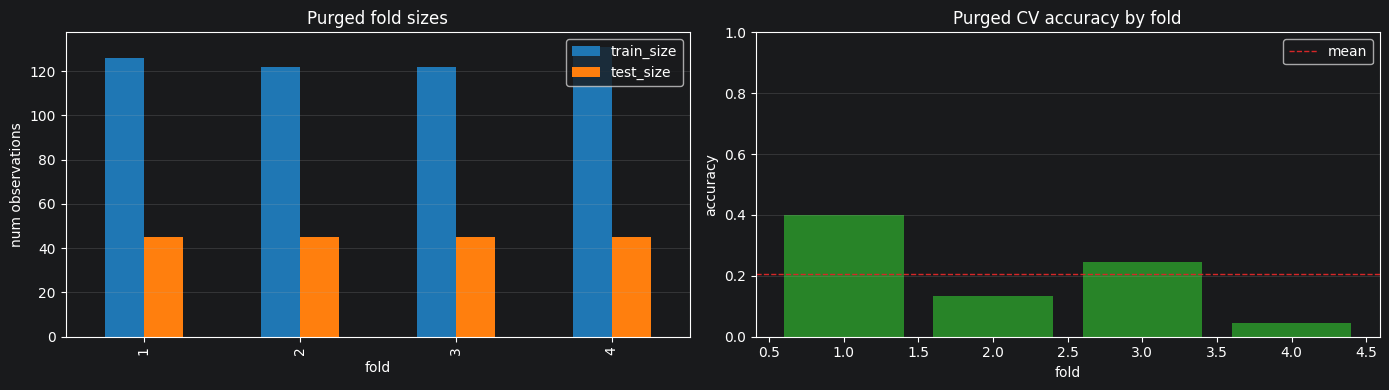

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fold_summary[["train_size", "test_size"]].plot(kind="bar", ax=axes[0], color=["tab:blue", "tab:orange"])
axes[0].set_title("Purged fold sizes")
axes[0].set_xlabel("fold")
axes[0].set_ylabel("num observations")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(np.arange(1, len(cv_scores) + 1), cv_scores, color="tab:green", alpha=0.8)
axes[1].axhline(cv_scores.mean(), color="tab:red", ls="--", lw=1, label="mean")
axes[1].set_title("Purged CV accuracy by fold")
axes[1].set_xlabel("fold")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()

### Interpretation

The fold table confirms that every test fold has `45` observations while the purged training size changes by fold.
- The training sizes are `126`, `122`, `122`, and `131`, so the middle folds lose more observations to overlapping label horizons and embargo rules.
- The decision tree scores are `[0.4000, 0.1333, 0.2444, 0.0444]`, with mean accuracy `0.2056`.
- The low and uneven score is useful in this demonstration: it shows that the notebook is evaluating on strict future/held-out blocks instead of reusing nearby overlapping observations.